# Task 6:

In [21]:
import pandas as pd
import numpy as np
#Loading the downlaoded Kaggle dataset using Pandas
df=pd.read_csv("dirty_cafe_sales.csv")

In [22]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [59]:
#Handling missing values in the dataset
# Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object','string']).columns

cat_cols
# Fill numerical columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode (or 'Unknown' if mode not available)
for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [54]:
#dropping duplicate rows from the dataframe
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape[0])

Duplicate rows: 0
10000


In [42]:
#Rename Columns (lowercase + snake_case)
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(' ', '_')
)

df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='str')

In [60]:
df.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-12-02


In [61]:
#datatype of each column in the dataframe before conversion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  str           
 1   item              10000 non-null  str           
 2   quantity          10000 non-null  float64       
 3   price_per_unit    10000 non-null  float64       
 4   total_spent       10000 non-null  float64       
 5   payment_method    10000 non-null  str           
 6   location          10000 non-null  str           
 7   transaction_date  9540 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 625.1 KB


In [64]:
#Fix Incorrect Data Types
# Convert them back to numeric:
df['price_per_unit'] = pd.to_numeric(
    df['price_per_unit'],
    errors='coerce'
)

df['quantity'] = pd.to_numeric(
    df['quantity'],
    errors='coerce'
)

df['total_spent'] = pd.to_numeric(
    df['total_spent'],
    errors='coerce'
)

#Converting to Dates
df['transaction_date'] = pd.to_datetime(
    df['transaction_date']
)

df['transaction_date'] = df['transaction_date'].fillna(
    df['transaction_date'].mode()[0]
)

In [65]:
df.dtypes

transaction_id                 str
item                           str
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method                 str
location                       str
transaction_date    datetime64[us]
dtype: object

In [66]:
print(" CLEANED DATA INFO ")
df.info()

print(" SAMPLE DATA")
print(df.head())

 CLEANED DATA INFO 
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  str           
 1   item              10000 non-null  str           
 2   quantity          10000 non-null  float64       
 3   price_per_unit    10000 non-null  float64       
 4   total_spent       10000 non-null  float64       
 5   payment_method    10000 non-null  str           
 6   location          10000 non-null  str           
 7   transaction_date  10000 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 625.1 KB
 SAMPLE DATA
  transaction_id    item  quantity  price_per_unit  total_spent  \
0    TXN_1961373  Coffee       2.0             2.0          4.0   
1    TXN_4977031    Cake       4.0             3.0         12.0   
2    TXN_4271903  Cookie       4.0             1.0          8

# Task 7:

In [67]:
#Hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

In [74]:
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
 
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\DELL\AppData\Local\Temp\ipykernel_16824\2769537931.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


In [75]:
df_encoded.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,1056,1,2.0,2.0,4.0,1,1,2023-09-08
1,4473,0,4.0,3.0,12.0,0,0,2023-05-16
2,3698,2,4.0,1.0,8.0,1,0,2023-07-19
3,6754,4,2.0,5.0,10.0,2,1,2023-04-27
4,2436,1,2.0,2.0,4.0,2,0,2023-06-11


# Sepearte Features and Target

In [76]:
X = df_encoded.drop('total_spent', axis=1)
y = df_encoded['total_spent']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 7)
Target shape: (10000,)


Task 8

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object','string']).columns

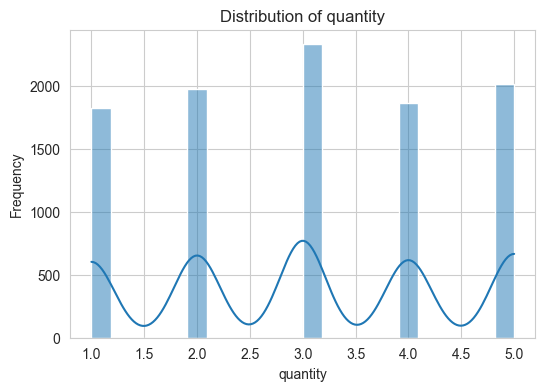

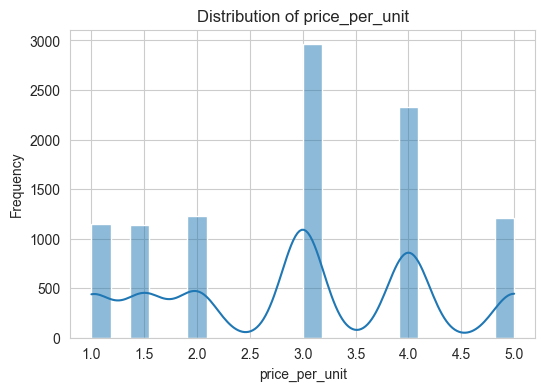

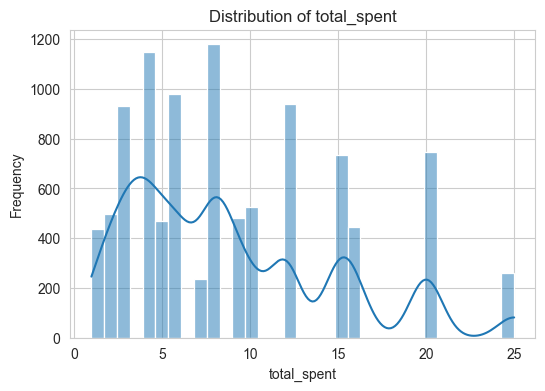

In [ ]:
#Histogram and KDE
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

In [84]:
print (cat_cols )

Index(['transaction_id', 'item', 'payment_method', 'location'], dtype='str')


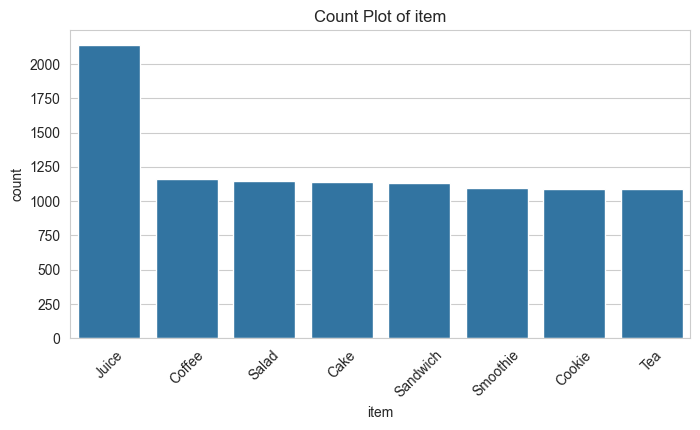

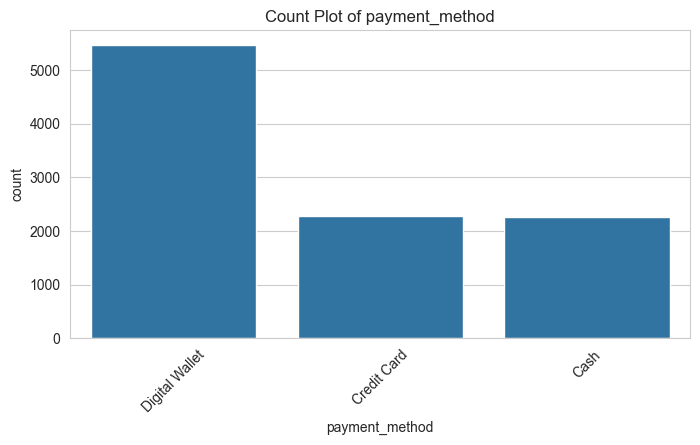

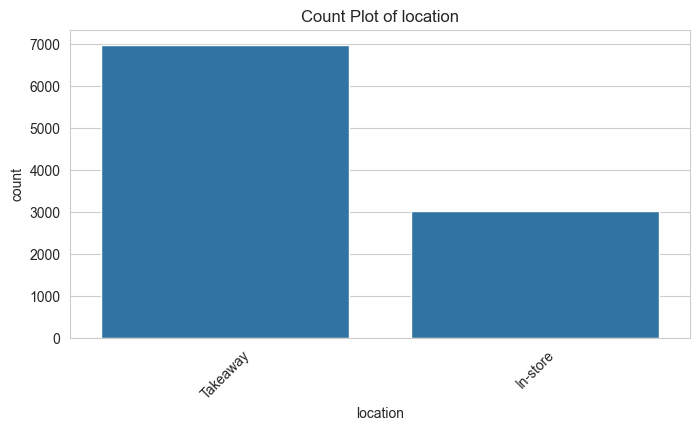

In [85]:
#Count Plots 
cat_cols = ['item', 'payment_method', 'location']
for col in cat_cols:
    plt.figure(figsize=(8,4))

    sns.countplot(
        x=df[col],
        order=df[col].value_counts().index
    )

    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)

    plt.show()

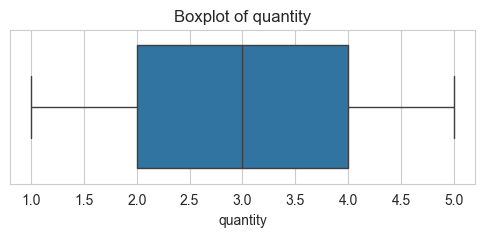

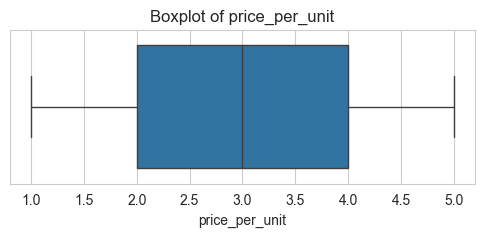

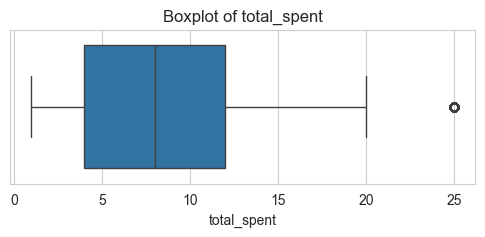

In [82]:
#Box plots
for col in num_cols:
    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

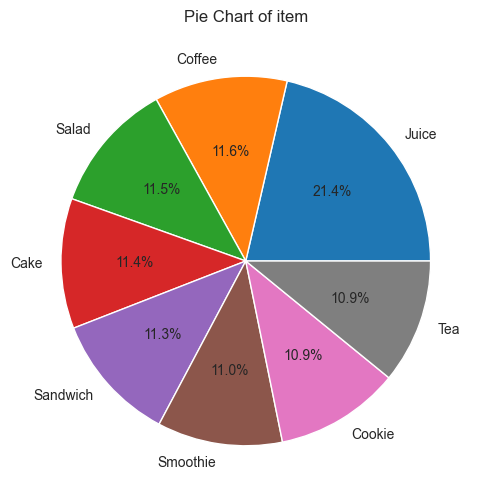

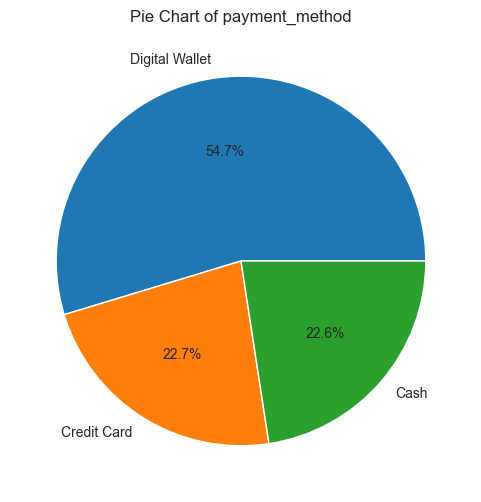

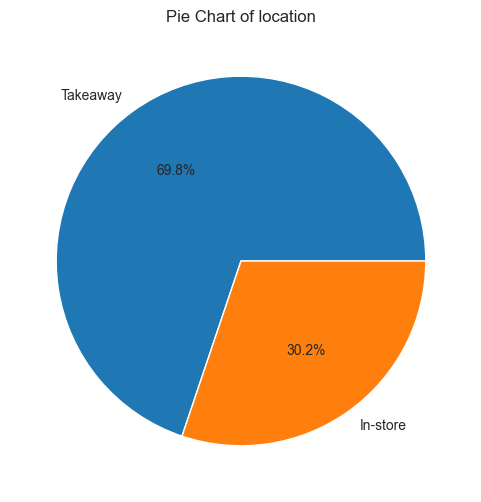

In [86]:
# Additonal - Pie Chart
for col in cat_cols:

    plt.figure(figsize=(6,6))

    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )

    plt.title(f"Pie Chart of {col}")

    plt.ylabel('')

    plt.show()

Task 9

In [89]:
#Column Selection
num_cols = df.select_dtypes(include='number').columns

cat_cols = [
    'item',
    'payment_method',
    'location'
]

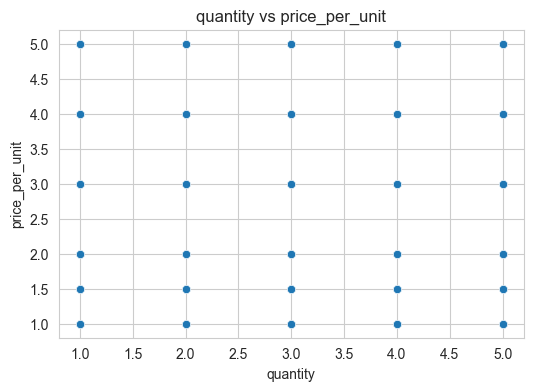

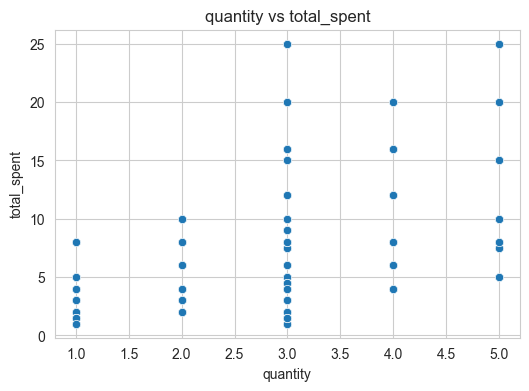

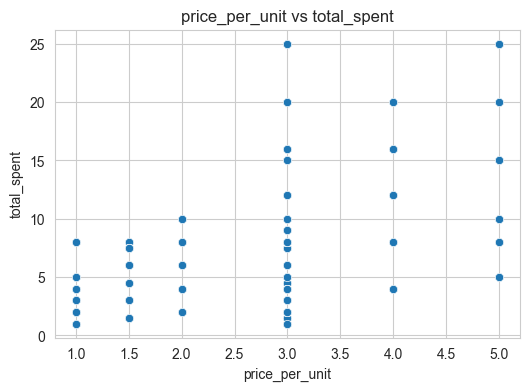

In [91]:
#scatter plot
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):

        plt.figure(figsize=(6,4))

        sns.scatterplot(
            data=df,
            x=num_cols[i],
            y=num_cols[j]
        )

        plt.title(f'{num_cols[i]} vs {num_cols[j]}')

        plt.show()

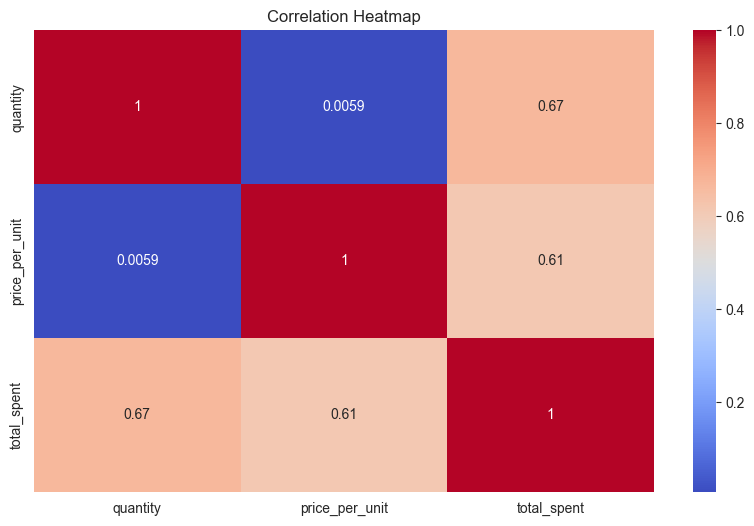

In [92]:
#Corelation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

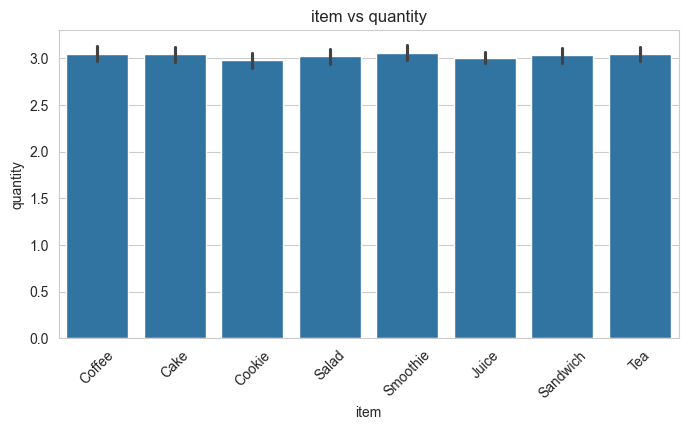

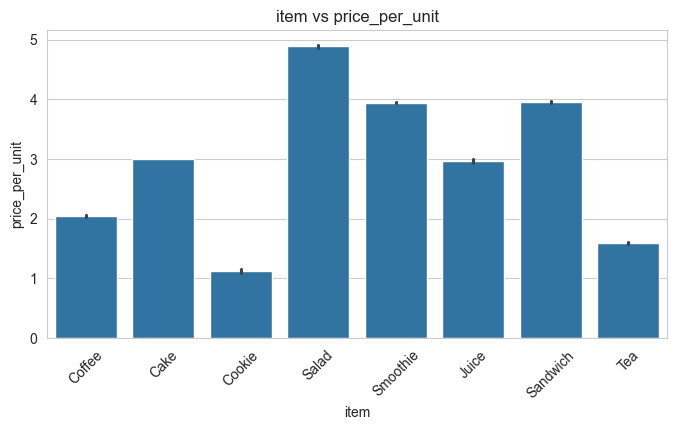

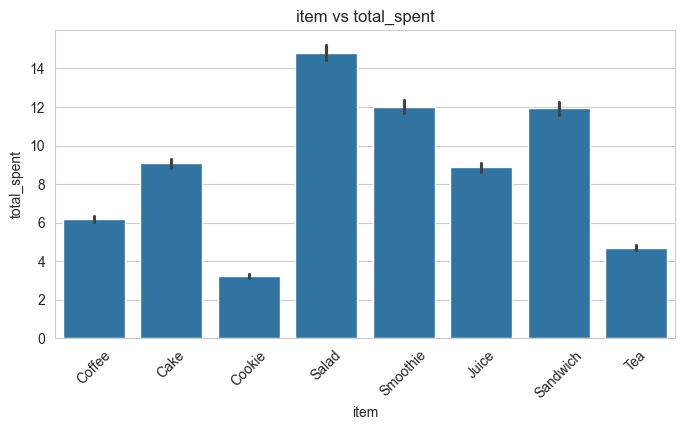

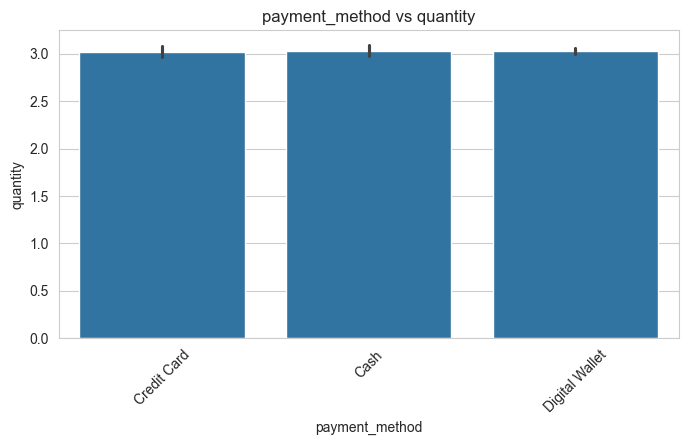

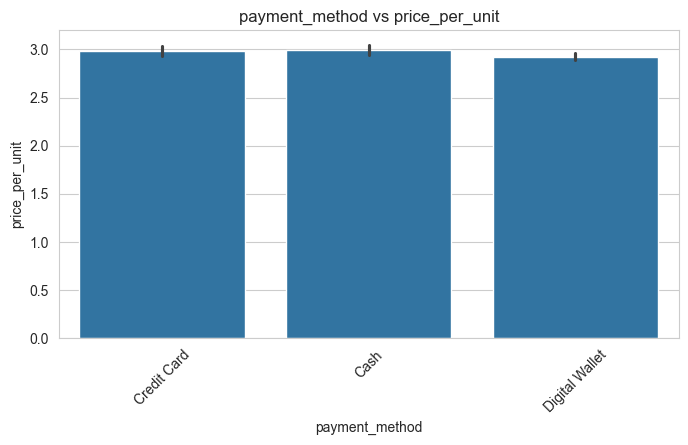

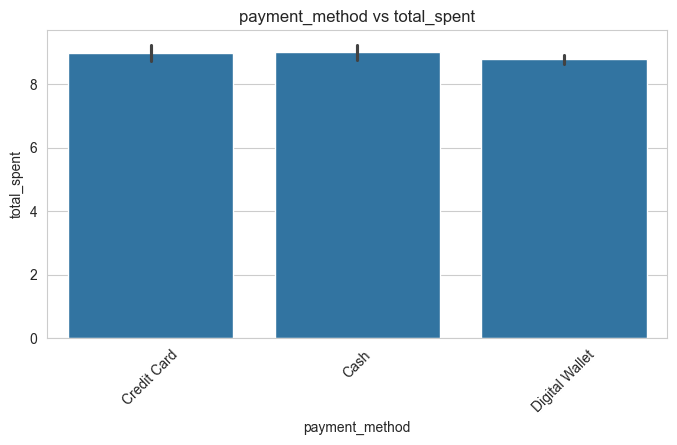

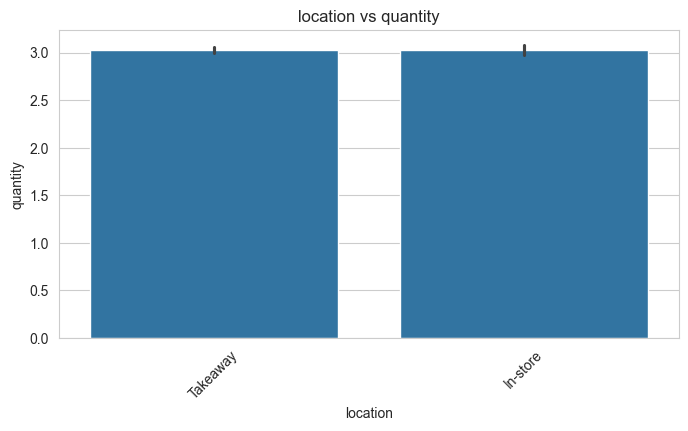

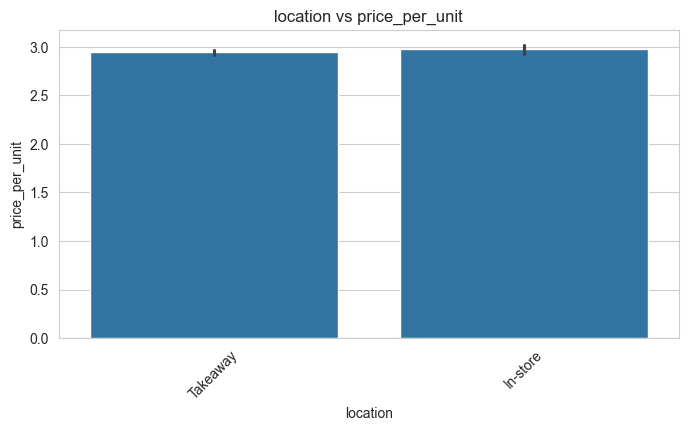

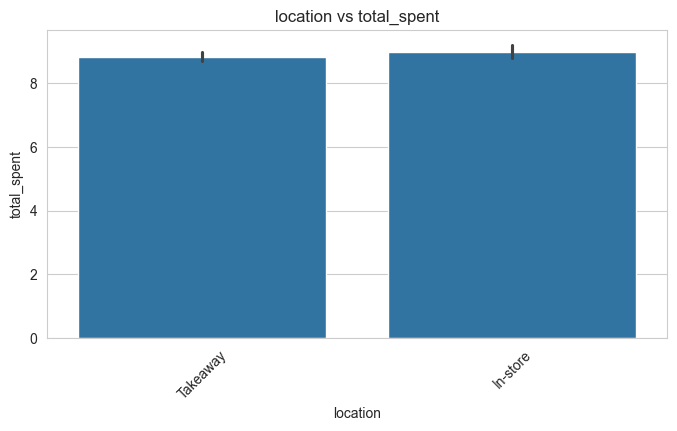

In [98]:
#Bar plot for categorical vs numerical
for cat in cat_cols:
    for num in num_cols:

        plt.figure(figsize=(8,4))

        sns.barplot(
            data=df,
            x=cat,
            y=num
        )

        plt.title(f'{cat} vs {num}')

        plt.xticks(rotation=45)

        plt.show()

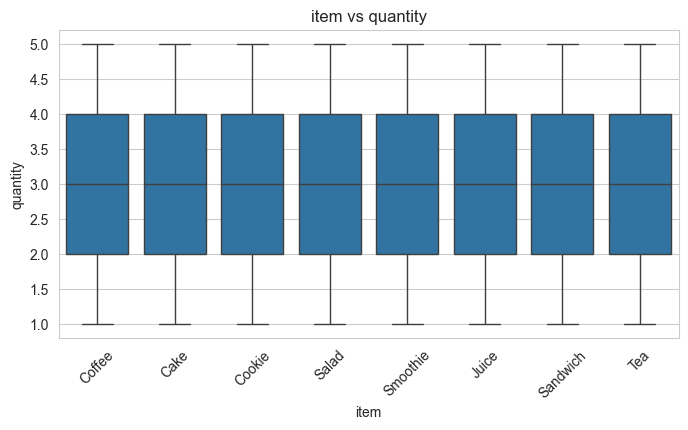

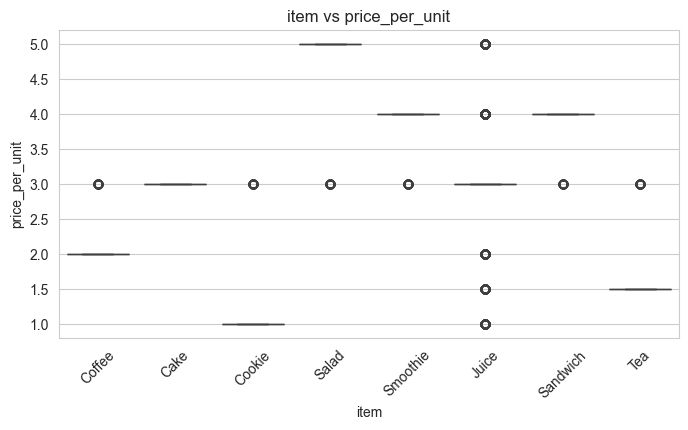

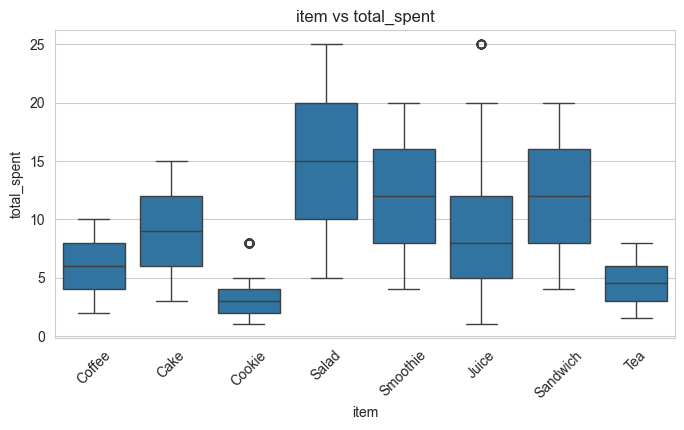

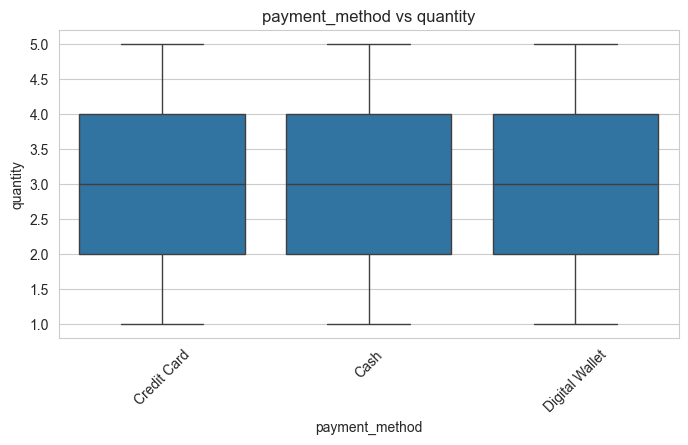

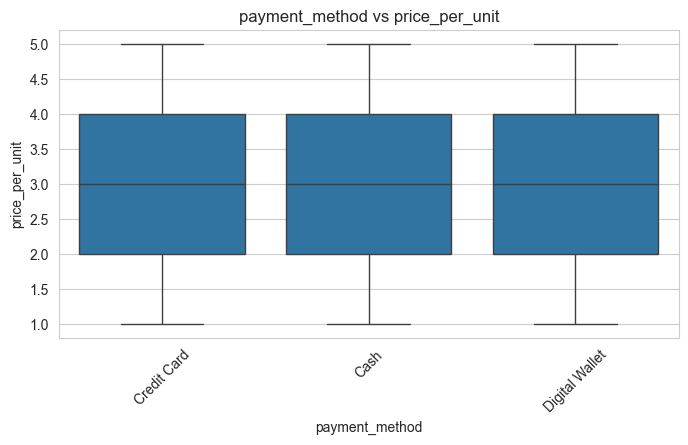

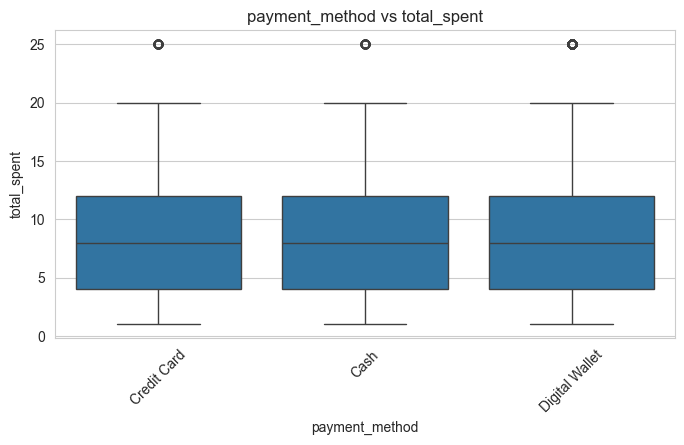

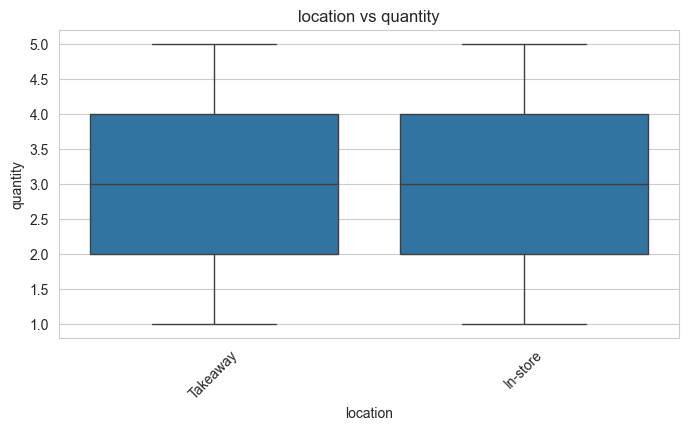

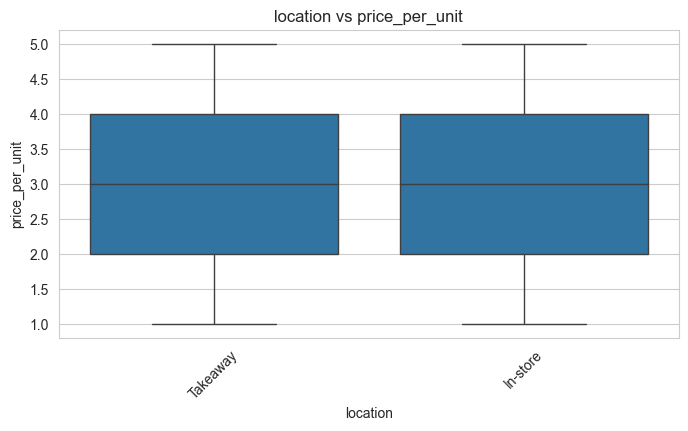

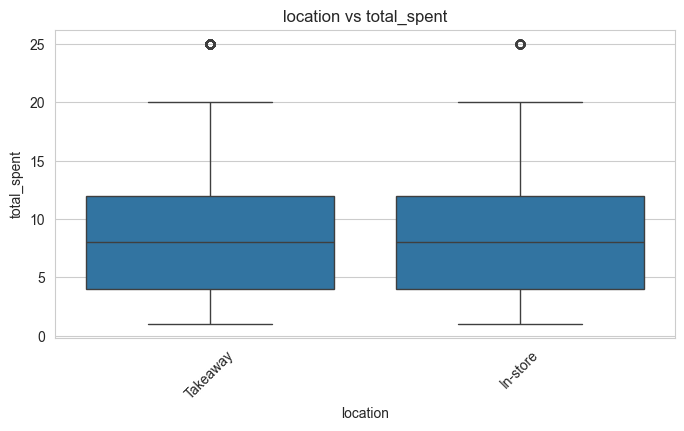

In [99]:
for cat in cat_cols:
    for num in num_cols:

        plt.figure(figsize=(8,4))

        sns.boxplot(
            data=df,
            x=cat,
            y=num
        )

        plt.title(f'{cat} vs {num}')

        plt.xticks(rotation=45)

        plt.show()

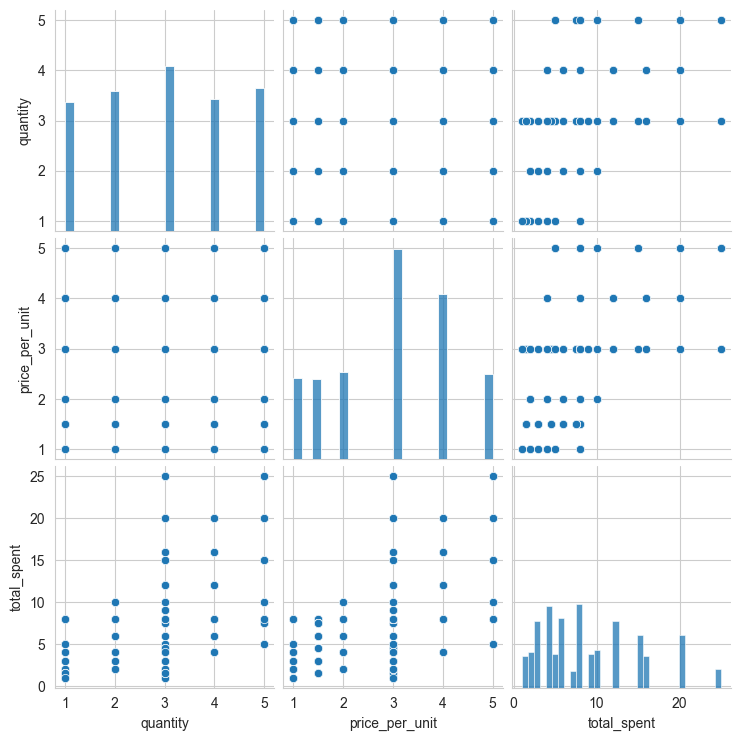

In [100]:
# Additonal - Pairplot
sns.pairplot(df[num_cols])

plt.show()

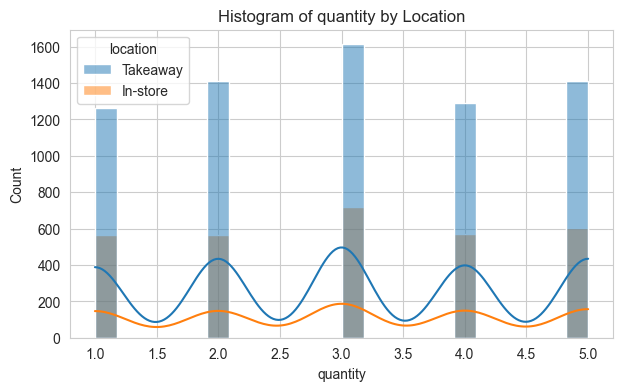

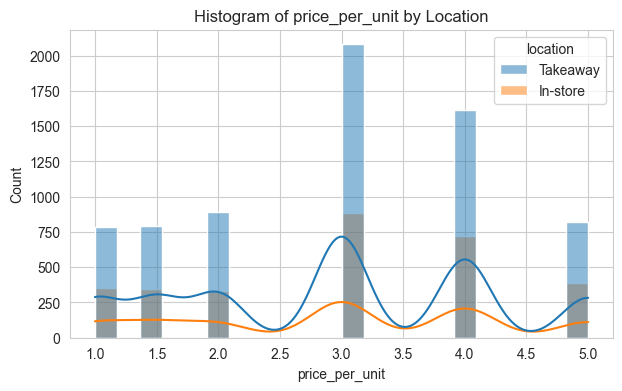

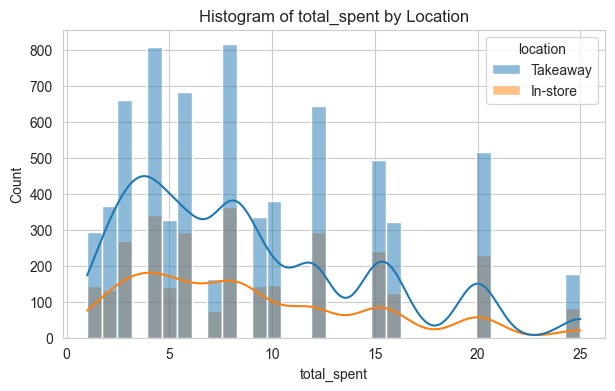

In [ ]:
#Histogram 
for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        hue='location',
        kde=True
    )

    plt.title(f'Histogram of {col} by Location')

    plt.show()

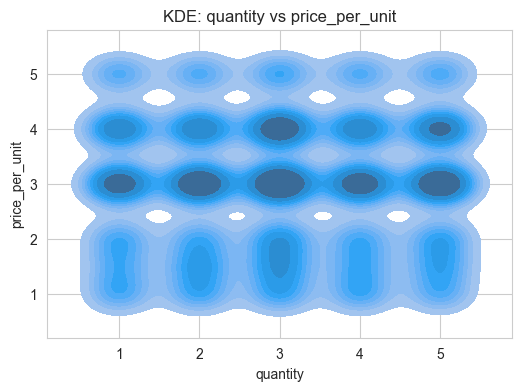

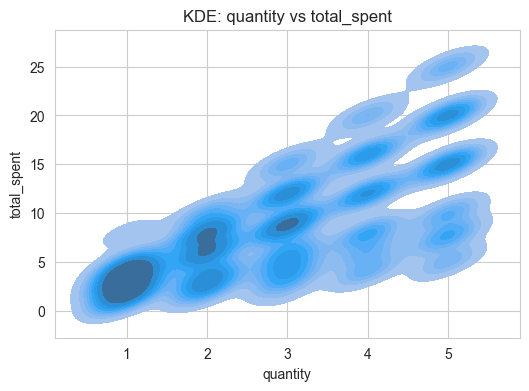

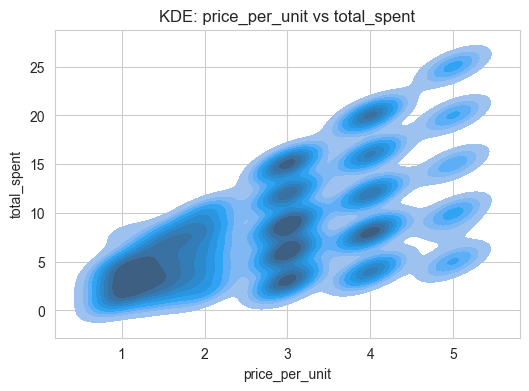

In [102]:
#KDE plot for bi variate analysis
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):

        plt.figure(figsize=(6,4))

        sns.kdeplot(
            data=df,
            x=num_cols[i],
            y=num_cols[j],
            fill=True
        )

        plt.title(
            f'KDE: {num_cols[i]} vs {num_cols[j]}'
        )

        plt.show()

Task 10

1. Most numerical columns are right-skewed, indicating higher frequency of lower values.
2. Significant outliers are present in columns like 'price' and 'total_spent'.
3. Strong correlation observed between 'quantity' and 'total_spent'.
4. Missing values and duplicates were present earlier, indicating data quality issues.